# Trend Analysis Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from utils import (
    fetch_prices, fetch_index,
    calc_monthly_returns,
    calc_trend_regime, calc_regime_stats,
    calc_trend_quintile,
    calc_momentum_signals, calc_quintile_from_signals,
    grid_search_quintile,
    plot_quadrant_scatter, plot_quadrant_trajectory, plot_regime_stats,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

In [5]:
# ---- Configuration ----
proxy = None                                                # e.g. "http://proxy:8080"

# Ticker list & display names
tickers = [
    "SMH", "IGV", "XAR", "XBI", "XME", "GDX", "XOP", "PAVE",
    "MGK", "MGV", "IWM", "SCHD", "USMV", "MTUM", "QUAL",
    "372330.KS", "487230.KS", "BOTZ", "SKYY", "ICLN", "AIQ"
]

ticker_names = {
    "SMH":       "Semiconductors",
    "IGV":       "Software",
    "XAR":       "Aerospace",
    "XBI":       "Biotech",
    "XME":       "Metals&Mining",
    "GDX":       "GoldMiners",
    "XOP":       "Oil&Gas",
    "PAVE":      "InfraDev",
    "MGK":       "Growth",
    "MGV":       "Value",
    "IWM":       "Small",
    "SCHD":      "Dividend",
    "USMV":      "MinVol",
    "MTUM":      "Momentum",
    "QUAL":      "Quality",
    "372330.KS": "HangSengTech",
    "487230.KS": "AI-Power",
    "BOTZ":      "Robot",
    "SKYY":      "CloudComputing",
    "ICLN":      "CleanEnergy",
    "AIQ":       "AI-Tech"
}

# Trend lookback (months)
fast_months = 2
slow_months = 9

# Composite rank weights
w_slow = 0.5
w_fast = 0.5

# Snapshot date for Quadrant Scatter (None = latest available month-end)
# e.g. "2024-12-31" or "2024-12" — picks the nearest month-end ≤ this date
#snapshot_date = "2026-03-31"
snapshot_date = None

## 1. Trend Cycle Quadrant Analysis

In [6]:
prices_multi = fetch_prices(tickers, start="1900-01-01", end="2026-12-31", proxy=proxy)
monthly_ret_multi = calc_monthly_returns(prices_multi)
regimes = calc_trend_regime(monthly_ret_multi, fast_months=fast_months, slow_months=slow_months)

# Resolve snapshot date: None → latest, otherwise nearest month-end ≤ snapshot_date
all_dates = regimes["date"]
if snapshot_date is None:
    snap_date = all_dates.max()
else:
    target = pd.Timestamp(snapshot_date)
    eligible = all_dates[all_dates <= target]
    if len(eligible) == 0:
        raise ValueError(f"No regime data on/before {snapshot_date}; earliest available is {all_dates.min().date()}")
    snap_date = eligible.max()

latest_date = snap_date  # kept name for downstream cells
latest = regimes[regimes["date"] == latest_date].copy()

print(f"Snapshot date: {latest_date.strftime('%Y-%m-%d')}  (Fast={fast_months}M, Slow={slow_months}M)")
latest[["ticker", "ret_fast", "ret_slow", "regime"]]

[*********************100%***********************]  21 of 21 completed


Snapshot date: 2026-04-30  (Fast=2M, Slow=9M)


,ticker,ret_fast,ret_slow,regime
12,372330.KS,-0.025293,-0.045134,Bearish
25,487230.KS,0.217812,0.395256,Bullish
38,AIQ,0.084361,0.223865,Bullish
51,BOTZ,-0.034854,0.130045,Correction
64,GDX,-0.235670,0.727015,Correction
77,ICLN,0.088913,0.491004,Bullish
90,IGV,0.042050,-0.238761,Rebound
103,IWM,0.049681,0.258482,Bullish
116,MGK,0.082748,0.102931,Bullish
129,MGV,-0.014447,0.167652,Correction


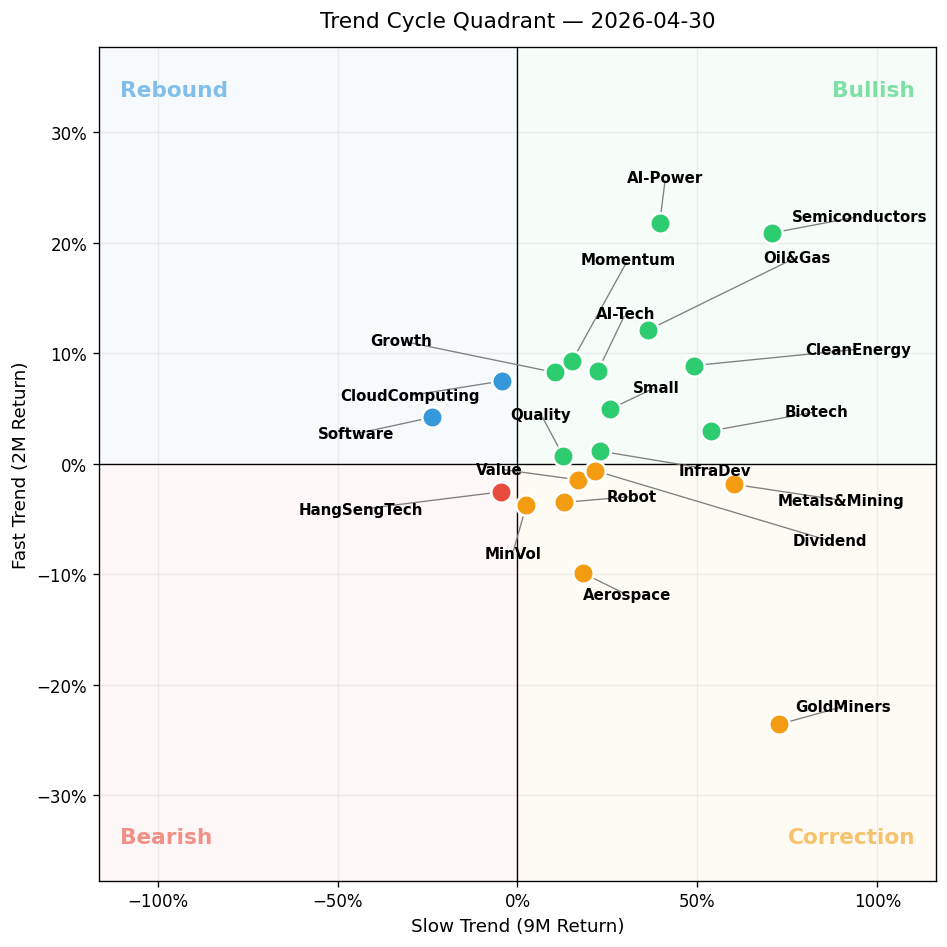

In [8]:
# Chart A: Quadrant Scatter
plot_quadrant_scatter(latest, snap_date=latest_date, ticker_names=ticker_names,
                      fast_months=fast_months, slow_months=slow_months)
plt.show()

In [ ]:
# Chart A2: Single-ticker trajectory through the quadrant
trajectory_ticker = "SMH"          # change to any ticker in the universe
trajectory_start = None            # e.g. "2022-01-31" (None → use lookback)
trajectory_end = snapshot_date     # None → latest available
trajectory_lookback = 36           # months back from end (ignored if start is set)

plot_quadrant_trajectory(
    regimes, ticker=trajectory_ticker, ticker_names=ticker_names,
    fast_months=fast_months, slow_months=slow_months,
    start_date=trajectory_start, end_date=trajectory_end,
    lookback_months=trajectory_lookback,
)
plt.show()

In [ ]:
# Chart B: Regime Statistics
regime_stats = calc_regime_stats(monthly_ret_multi, regimes)
plot_regime_stats(regime_stats, fast_months=fast_months, slow_months=slow_months)
plt.show()

## 2. Trend Quintile Analysis (Rank-Based)

In [6]:
# Quintile assignment
quintile_latest, quintile_stats = calc_trend_quintile(
    monthly_ret_multi, regimes, w_slow=w_slow, w_fast=w_fast
)

# Show current quintile assignments
quintile_latest["name"] = quintile_latest["ticker"].map(ticker_names)
display(quintile_latest[["ticker", "name", "ret_fast", "ret_slow",
                          "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))
print(f"\nLookback: Fast={fast_months}M, Slow={slow_months}M | Weights: Slow={w_slow}, Fast={w_fast}")
quintile_stats

,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
9,372330.KS,HangSengTech,-0.039482,-0.023255,2.0,3.0,2.5,Q1
169,USMV,MinVol,-0.034484,0.032303,3.0,4.0,3.5,Q1
99,MGV,Value,-0.011032,0.243754,6.0,6.0,6.0,Q1
69,IGV,Software,0.049160,-0.109191,1.0,11.0,6.0,Q1
129,QUAL,Quality,0.009817,0.230851,5.0,9.0,7.0,Q2
39,BOTZ,Robot,-0.031010,0.332858,10.0,5.0,7.5,Q2
139,SCHD,Dividend,-0.004080,0.262086,7.0,8.0,7.5,Q2
179,XAR,Aerospace,-0.094045,0.504522,14.0,2.0,8.0,Q2
49,GDX,GoldMiners,-0.225829,0.843120,18.0,1.0,9.5,Q3
149,SKYY,CloudComputing,0.087186,0.145479,4.0,16.0,10.0,Q3



Lookback: Fast=2M, Slow=12M | Weights: Slow=0.5, Fast=0.5


,mean,std,sharpe
Q1,0.004888,0.041678,0.117276
Q2,0.020659,0.040155,0.514490
Q3,0.033400,0.052702,0.633741
Q4,0.037130,0.043916,0.845475
Q5,0.031684,0.060716,0.521838


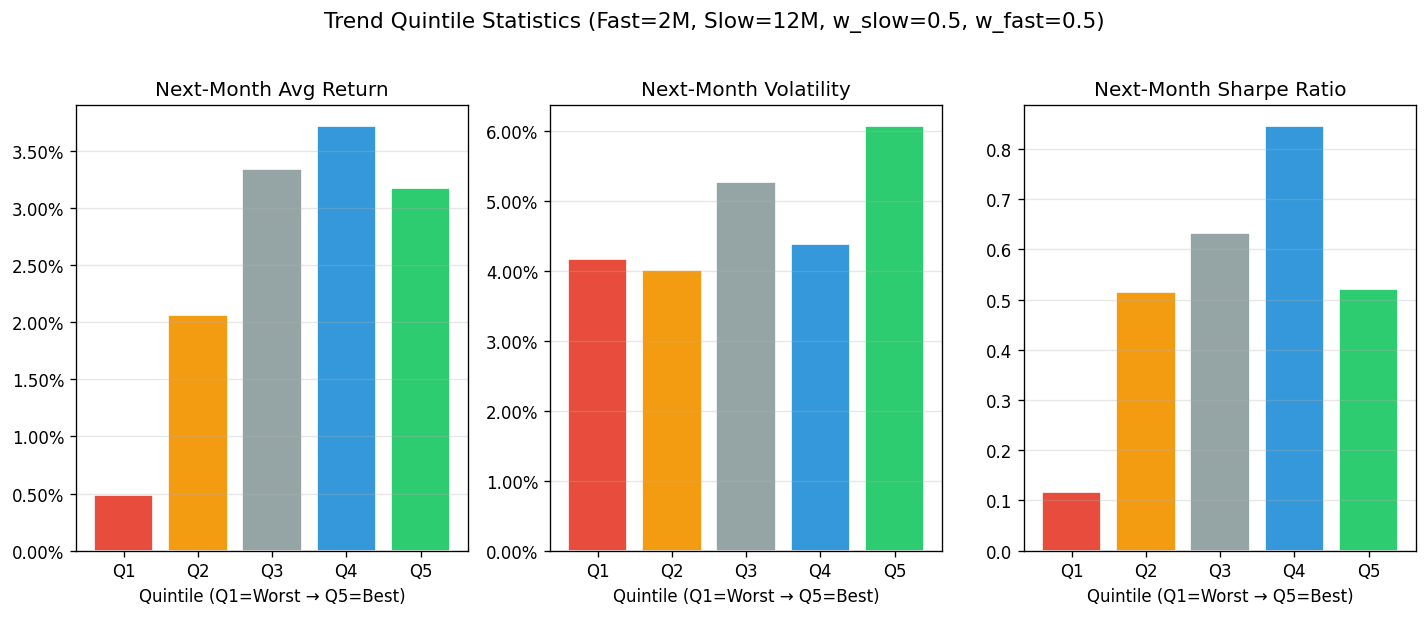

In [7]:
# Chart: Quintile Statistics
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Mean Return
axes[0].bar(q_labels, quintile_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Volatility
axes[1].bar(q_labels, quintile_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

# Sharpe
axes[2].bar(q_labels, quintile_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Trend Quintile Statistics (Fast={fast_months}M, Slow={slow_months}M, w_slow={w_slow}, w_fast={w_fast})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Grid Search — Optimal Fast/Slow Lookback & Weights

In [8]:
%%time
# Grid search: find combo that maximizes Q5-Q1 Sharpe spread
# Results sorted by: (1) fewest monotonicity violations, (2) largest spread
grid_results = grid_search_quintile(
    monthly_ret_multi,
    fast_list=[1, 2, 3],
    slow_list=[6, 9, 10, 11, 12],
    weight_step=0.1,
)

n_mono = grid_results["is_monotonic"].sum()
n_near = (grid_results["mono_violations"] <= 1).sum()
print(f"Total combos tested: {len(grid_results)}")
print(f"Strictly monotonic (0 violations): {n_mono}")
print(f"Near-monotonic (≤1 violation): {n_near}")

# Show near-monotonic combos (≤1 violation), sorted by spread
near_mono = grid_results[grid_results["mono_violations"] <= 1]
print(f"\nTop 15 near-monotonic combos:")
near_mono[["fast_months", "slow_months", "w_slow", "w_fast",
           "sharpe_Q1", "sharpe_Q2", "sharpe_Q3", "sharpe_Q4", "sharpe_Q5",
           "sharpe_spread", "mono_violations"]].head(15)

Total combos tested: 165
Strictly monotonic (0 violations): 4
Near-monotonic (≤1 violation): 80

Top 15 near-monotonic combos:
CPU times: user 7.8 s, sys: 4.15 ms, total: 7.8 s
Wall time: 7.74 s


,fast_months,slow_months,w_slow,w_fast,sharpe_Q1,sharpe_Q2,sharpe_Q3,sharpe_Q4,sharpe_Q5,sharpe_spread,mono_violations
0,2,9,0.4,0.6,0.355693,0.579507,0.730163,0.948942,1.017120,0.661427,0
1,2,10,0.4,0.6,0.274137,0.534412,0.587580,0.884770,0.924517,0.650380,0
2,3,9,0.2,0.8,0.356466,0.618739,0.791769,0.793592,0.850249,0.493783,0
3,3,6,0.0,1.0,0.364592,0.367723,0.398274,0.477872,0.562468,0.197876,0
4,3,11,0.3,0.7,-0.025613,0.653330,0.786657,0.572217,0.754986,0.780599,1
5,3,10,0.3,0.7,0.079192,0.677183,0.931617,0.683054,0.819746,0.740554,1
6,3,10,0.2,0.8,0.110002,0.607265,0.855651,0.709819,0.816001,0.705999,1
7,3,11,0.2,0.8,0.051375,0.575236,0.701615,0.630912,0.746645,0.695270,1
8,3,11,0.4,0.6,-0.005668,0.741311,0.960023,0.514846,0.688926,0.694594,1
9,2,10,0.2,0.8,0.266662,0.854445,0.324888,0.830375,0.946591,0.679929,1


Best combo (monotonic): Fast=2M, Slow=9M, w_slow=0.4, w_fast=0.6
  Q1→Q5 Sharpe: 0.356 → 0.580 → 0.730 → 0.949 → 1.017
  Spread: 0.661


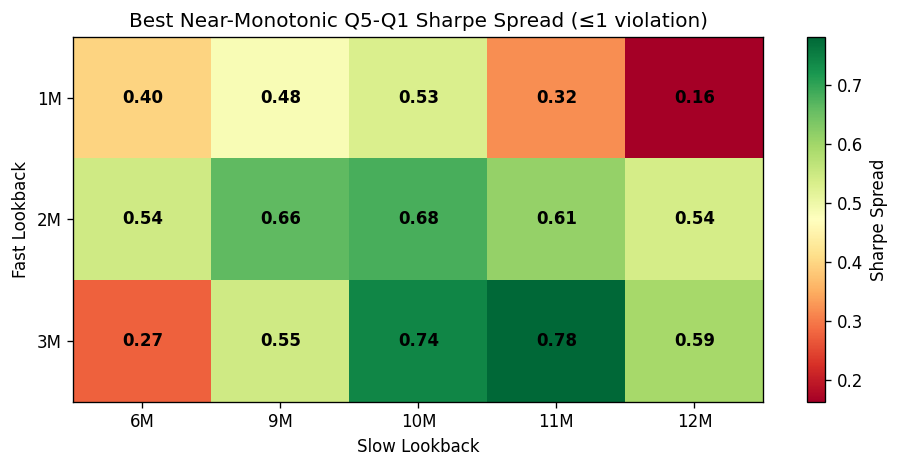

In [9]:
# Visualize grid search results
# Pick best: strictly monotonic first, then ≤1 violation, then best overall
mono_results = grid_results[grid_results["is_monotonic"]]
near_results = grid_results[grid_results["mono_violations"] <= 1]

if len(mono_results) > 0:
    best = mono_results.iloc[0]
    label = "monotonic"
elif len(near_results) > 0:
    best = near_results.iloc[0]
    label = f"near-monotonic ({int(best['mono_violations'])} violation)"
else:
    best = grid_results.iloc[0]
    label = f"{int(best['mono_violations'])} violations"

print(f"Best combo ({label}): "
      f"Fast={int(best['fast_months'])}M, Slow={int(best['slow_months'])}M, "
      f"w_slow={best['w_slow']:.1f}, w_fast={best['w_fast']:.1f}")
print(f"  Q1→Q5 Sharpe: {best['sharpe_Q1']:.3f} → {best['sharpe_Q2']:.3f} → "
      f"{best['sharpe_Q3']:.3f} → {best['sharpe_Q4']:.3f} → {best['sharpe_Q5']:.3f}")
print(f"  Spread: {best['sharpe_spread']:.3f}")

# Heatmap: for each (fast, slow) pair, show best sharpe_spread among ≤1 violation combos
pivot_src = near_results if len(near_results) > 0 else grid_results
hm_pivot = pivot_src.groupby(["fast_months", "slow_months"])["sharpe_spread"].max().unstack()

if not hm_pivot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(hm_pivot.values, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(hm_pivot.columns)))
    ax.set_xticklabels([f"{int(c)}M" for c in hm_pivot.columns])
    ax.set_yticks(range(len(hm_pivot.index)))
    ax.set_yticklabels([f"{int(r)}M" for r in hm_pivot.index])
    ax.set_xlabel("Slow Lookback")
    ax.set_ylabel("Fast Lookback")
    ax.set_title("Best Near-Monotonic Q5-Q1 Sharpe Spread (≤1 violation)")

    for i in range(len(hm_pivot.index)):
        for j in range(len(hm_pivot.columns)):
            val = hm_pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Sharpe Spread")
    plt.tight_layout()
    plt.show()

Selected: #0 → Fast=2M, Slow=9M, w_slow=0.4, w_fast=0.6  (violations=0, spread=0.661)


,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
12,372330.KS,HangSengTech,-0.039482,-0.059034,2.0,3.0,2.6,Q1
220,USMV,MinVol,-0.034484,0.027918,4.0,4.0,4.0,Q1
233,XAR,Aerospace,-0.094045,0.187042,10.0,2.0,5.2,Q1
51,BOTZ,Robot,-0.031010,0.134546,7.0,5.0,5.8,Q1
90,IGV,Software,0.049160,-0.233566,1.0,11.0,7.0,Q2
129,MGV,Value,-0.011032,0.171698,9.0,6.0,7.2,Q2
168,QUAL,Quality,0.009817,0.129783,6.0,9.0,7.8,Q2
64,GDX,GoldMiners,-0.225829,0.749251,21.0,1.0,9.0,Q2
181,SCHD,Dividend,-0.004080,0.217743,11.0,8.0,9.2,Q3
116,MGK,Growth,0.080873,0.101021,5.0,14.0,10.4,Q3


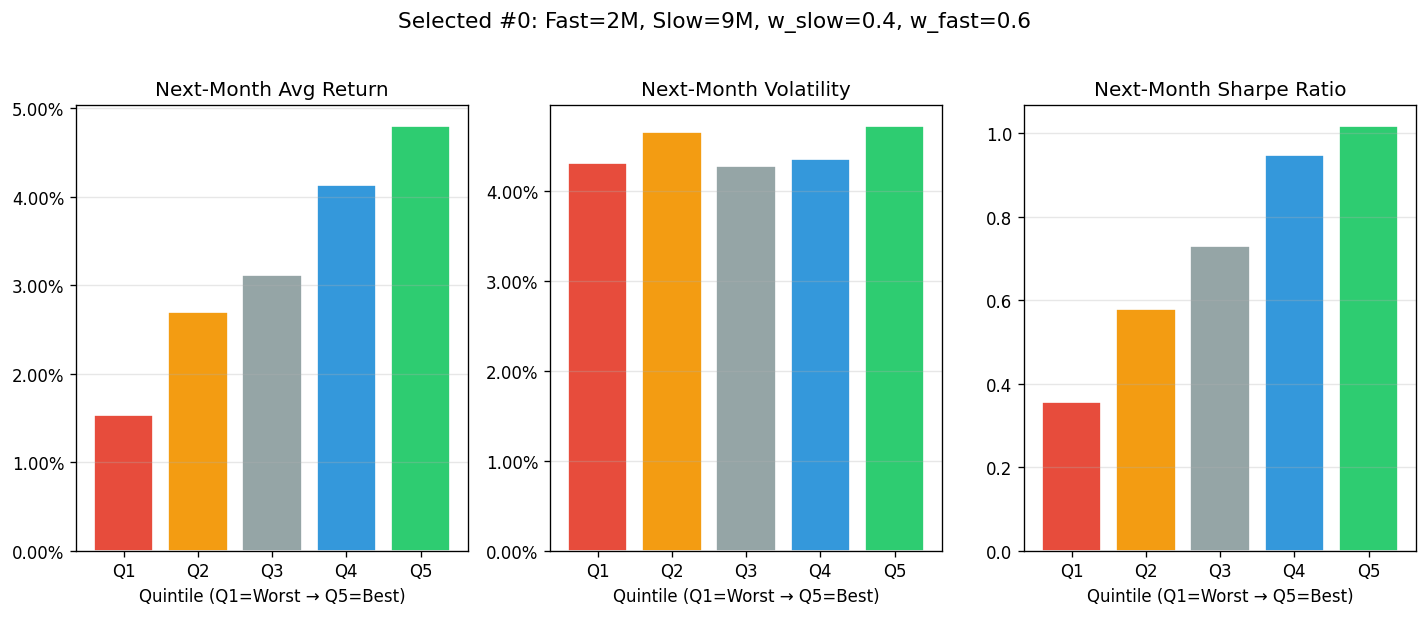

In [10]:
# ---- Select combo from near-monotonic results (0-indexed from table above) ----
selected_rank = 0  # Change this: 0 = 1st row, 2 = 3rd row, etc.

# Rerun quintile analysis with selected combo from grid search
sel = near_mono.iloc[selected_rank]
sel_fast = int(sel["fast_months"])
sel_slow = int(sel["slow_months"])
sel_ws = sel["w_slow"]
sel_wf = sel["w_fast"]

print(f"Selected: #{selected_rank} → Fast={sel_fast}M, Slow={sel_slow}M, "
      f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}  "
      f"(violations={int(sel['mono_violations'])}, spread={sel['sharpe_spread']:.3f})")

sel_signals = calc_momentum_signals(monthly_ret_multi, fast_months=sel_fast, slow_months=sel_slow)
sel_q_latest, sel_q_stats = calc_quintile_from_signals(
    monthly_ret_multi, sel_signals, w_slow=sel_ws, w_fast=sel_wf
)

# Show assignments
sel_q_latest["name"] = sel_q_latest["ticker"].map(ticker_names)
display(sel_q_latest[["ticker", "name", "ret_fast", "ret_slow",
                       "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))

# Chart
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(q_labels, sel_q_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(q_labels, sel_q_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(q_labels, sel_q_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Selected #{selected_rank}: Fast={sel_fast}M, Slow={sel_slow}M, "
             f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()